# Demo: Adding Jitter

This tutorial demonstrates how to add jitter to a **corgisim** simulation by including an additional dictionary when setting up the optics.

In [5]:
# Import the necessary packages
import numpy as np
import matplotlib.pyplot as plt
from corgisim import scene, instrument, inputs, observation, jitter
from corgisim.scene import SimulatedImage
import proper
import roman_preflight_proper
roman_preflight_proper.copy_here()

## Step 1: Define the astrophysical scene

The first step is to define the host star properties. For this example, we will model the host star as a point source.

In [6]:
# Define the host star properties
Vmag = 8
sptype = 'G0V'

host_star_properties = {'Vmag':Vmag, 'spectral_type': sptype, 'magtype':'vegamag'}

The next step is to define any companions. For this example, we will not include any companions.

Next, we set up the Scene object.

In [7]:
base_scene = scene.Scene(host_star_properties)

## Step 2: Define the optics 

The optics keywords are set up as usual.

In [8]:
# Set up the optics keywords
cgi_mode = 'excam'
bandpass_corgisim = '1F'
cor_type = 'hlc_band1'
cases = ['3e-8']
rootname = 'hlc_ni_' + cases[0]
dm1 = proper.prop_fits_read( roman_preflight_proper.lib_dir + '/examples/'+rootname+'_dm1_v.fits' )
dm2 = proper.prop_fits_read( roman_preflight_proper.lib_dir + '/examples/'+rootname+'_dm2_v.fits' )

optics_keywords ={'cor_type':cor_type, 'use_errors':1, 'polaxis':10, 'output_dim':201,\
                  'use_dm1':1, 'dm1_v':dm1, 'use_dm2':1, 'dm2_v':dm2,'use_fpm':1,\
                  'use_lyot_stop':1,  'use_field_stop':1 }

An additional dictionary, stellar_diam_and_jitter_keywords, is needed to provide the parameters for the jitter model and to specify that this model should be used. Without this dictionary, corgisim will default to a jitter-free simulation.

This dictionary must contain the key-value pair 'add_jitter':1 for a simulation that includes jitter. Otherwise, **corgisim** will default to a jitter-free case. 

Jitter is modeled by defining a set of offset sources in addition to the on-axis point source, weighting the intensity contribution from each of these sources, and combining the weighted intensities. The offset source distribution in **corgisim** is built from concentric rings of offset sources, and it is defined by the following six parameters:

1. **N_rings_of_offsets**: The number of rings of offset sources, not counting the 0th ring containing only the on-axis source
2. **N_offsets_per_ring**: An array containing the number of offset sources in each ring of the distribution, excluding the 0th ring
3. **starting_offset_ang_by_ring**: An array containing the angle in degrees that places the first offset source in each ring, excluding the 0th ring
4. **r_ring0**: The radius in mas of the 0th ring, which contains the on-axis source
5. **dr_rings**: An array or scalar defining the width of each ring in the distribution, excluding the 0th ring.
                 If dr_rings is a scalar, all rings past the 0th are assigned the same width.
6. **outer_radius_of_offset_circle**: The outer radius in mas of the offset circle.

The first three parameters are always required when defining a custom offset distribution. If r_ring0 is not defined, it defaults to 0.075 mas.

For simulations with jitter, outer_radius_of_offset_circle and/or dr_rings must be defined as well.

If outer_radius_of_offset_circle is not defined but ring widths are provided, outer_radius_of_offset_circle defaults to the sum of the ring widths. 

If the outer radius is provided but dr_rings is not defined, dr_rings defaults to (outer_radius_of_offset_circle - r_ring0) / N_rings_of_offsets.

The jitter model also requires the root-mean-square (RMS) jitter in mas in the x and y directions (**jitter_sigmax** and **jitter_sigmay**, respectively).

For this example, we will use an offset source distribution that extends out to 3.375 mas and contains 35 offsets in 5 rings in addition to the on-axis source in the 0th ring. We will also assume that the RMS jitter is 0.317 mas in the x direction and 0.308 mas in the y direction.

In [9]:
# Set up the dictionary containing the jitter model parameters
stellar_diam_and_jitter_keywords = {'add_jitter':1,'jitter_sigmax':0.317,'jitter_sigmay':0.308,\
                                    'N_rings_of_offsets':5,'N_offsets_per_ring':np.array([3,5,7,10,10]),\
                                    'starting_offset_ang_by_ring':np.array([90,0,45,0,90]),'r_ring0':0.075,\
                                    'dr_rings':np.array([0.3,0.3,0.3,0.8,1.6]),\
                                    'outer_radius_of_offset_circle':3.375}

The stellar_diam_and_jitter_keywords dictionary is used when setting up the optics. It must be included in this step, or **corgisim** will default to a jitter-free case.

In [10]:
optics = instrument.CorgiOptics(cgi_mode, bandpass_corgisim, optics_keywords=optics_keywords,\
                                stellar_diam_and_jitter_keywords=stellar_diam_and_jitter_keywords, if_quiet=True)

CorgiOptics initialized with proper keywords.


From this point on, the steps are the same as in other tutorials.

**A note about runtime**: In the jitter model, the star's intensity is a weighted sum of the intensities of the sources in the distribution. This means that the model can be a bit time consuming to run if **corgisim** needs to propagate each source. One time-saving technique is to estimate the electric field of each source instead of doing a propagation. For this approximation, the delta electric field at time 0 is calculated for each offset source (as the off-axis field minus the on-axis field). Then, for later times, each offset field is estimated by adding the appropriate delta to the on-axis field, and each offset field is converted to an intensity. This approximation can be more than two orders of magnitude faster than propagating each source.
    
Currently, the first run of the jitter model is slow because **corgisim** propagates each source, calculates the delta electric fields, and stores the delta electric fields in stellar_diam_and_jitter_keywords. Subsequent runs are faster because **corgisim** uses the delta electric fields. A future update to **corgisim** will allow libraries of delta electric fields to be saved and loaded to speed up the first run as well.

## Step 3: Simulate the image on the detector

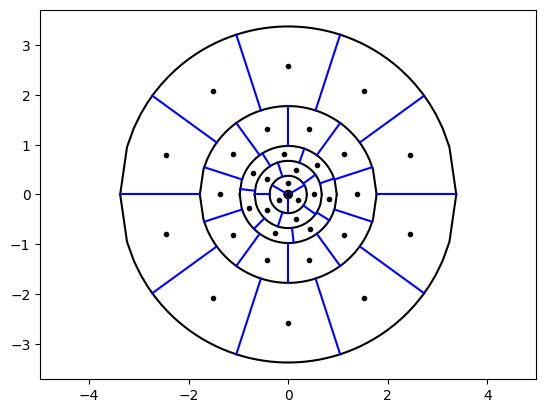

In [11]:
# Optional: Plotting the distribution of offset sources and the region represented by each

# Step 1: Use jitter.Determine_offsets_and_areas to calculate the set of offset source locations 
#         and sets of coordinates that define the boundaries of the regions represented by each source
x_offsets, y_offsets, A_offsets, x_outer_dict, yu_outer_dict, yl_outer_dict, boundary_coords_dict = \
jitter.Determine_offsets_and_areas(stellar_diam_and_jitter_keywords['outer_radius_of_offset_circle'],\
                                   stellar_diam_and_jitter_keywords['N_rings_of_offsets'], \
                                   stellar_diam_and_jitter_keywords['N_offsets_per_ring'],\
                                   stellar_diam_and_jitter_keywords['starting_offset_ang_by_ring'],\
                                   stellar_diam_and_jitter_keywords['r_ring0'],\
                                   stellar_diam_and_jitter_keywords['dr_rings'])

# Step 2: Use jitter.Plot_ALL_Offsets_And_Region_Outlines to draw the figure
jitter.Plot_ALL_Offsets_And_Region_Outlines(x_offsets,y_offsets,x_outer_dict,\
                                            yu_outer_dict,yl_outer_dict,\
                                            boundary_coords_dict,\
                                            stellar_diam_and_jitter_keywords['N_rings_of_offsets'],\
                                            stellar_diam_and_jitter_keywords['N_offsets_per_ring'])

In [12]:
# emccd keywords
gain = 1000
emccd_keywords = {'em_gain':gain}

# Set up the detector
detector = instrument.CorgiDetector(emccd_keywords)

# Define the exposure time
exp_time = 2000

# Test a single frame (Note that this step takes a bit of time because corgisim is propagating each offset source in addition to the on-axis source.)
n_frames = 1
simulatedImage_list = observation.generate_observation_sequence(base_scene,optics,detector,exp_time,n_frames)

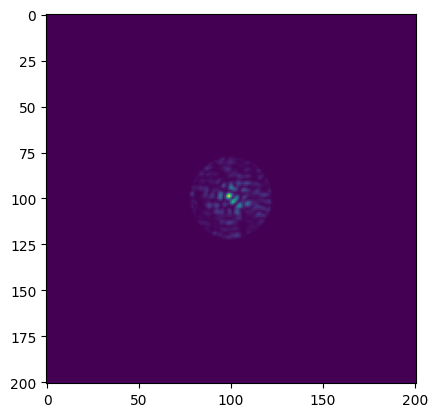

In [13]:
# Plot the host star image
host_star_image = simulatedImage_list[0].host_star_image.data
plt.imshow(host_star_image)